# Demo Pipeline Cham Trac Nghiem Tu Dong (OMR)

Pipeline 9 buoc: Doc anh → Xam → Loc nhieu → Canny → Tim goc → Nan chinh → Anchor/ROI → Doc SBD/Ma de → Cham diem

In [1]:
# ── Cell 0: Setup path va import ──
import os, sys
from pathlib import Path

# Xac dinh project root (thu muc cham-trac-nghiem-xla)
_notebook_dir = Path(os.path.abspath(''))
_project_root = _notebook_dir.parent if _notebook_dir.name == 'notebooks' else _notebook_dir
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))
os.chdir(_project_root)
print(f'Project root: {_project_root}')

import cv2
import numpy as np
import matplotlib.pyplot as plt
import json

from src.preprocessing import doc_anh, chuyen_xam, loc_nhieu
from src.transform import tim_canh, tim_goc_giay, nan_chinh_anh
from src.reader import (
    phat_hien_anchor, phan_loai_vung_roi,
    extract_exam_code_region, read_exam_code,
    extract_student_id_region, read_student_id,
    visualize_all_regions, visualize_anchors,
)
from src.grader import segment_bubbles, calculate_score, grade_from_image

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
print('Import thanh cong!')

Project root: e:\custom lại skills cho các ide\project-xla-tgmt\cham-trac-nghiem-xla
Import thanh cong!


## Buoc 1: Doc anh goc

Kich thuoc anh: (1024, 576, 3)


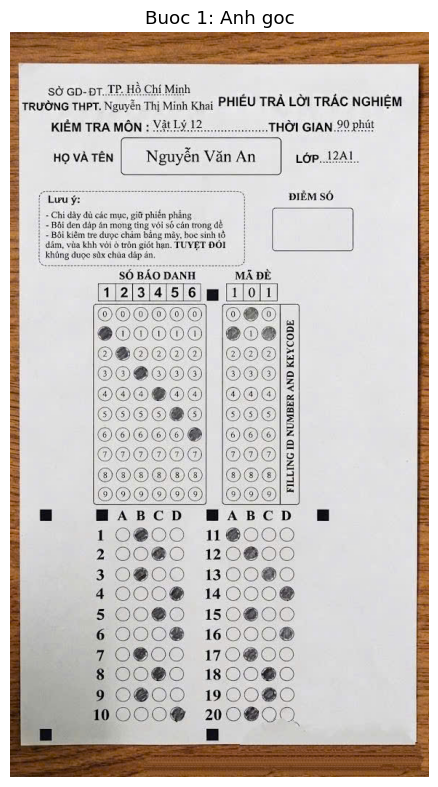

In [2]:
image_path = 'data/raw/test_sheet_01.jpg'
image = doc_anh(image_path)
print(f'Kich thuoc anh: {image.shape}')

fig, ax = plt.subplots(1, 1, figsize=(6, 8))
ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax.set_title('Buoc 1: Anh goc')
ax.axis('off')
plt.tight_layout()
plt.show()

## Buoc 2: Chuyen sang anh xam

Kich thuoc anh xam: (1024, 576)


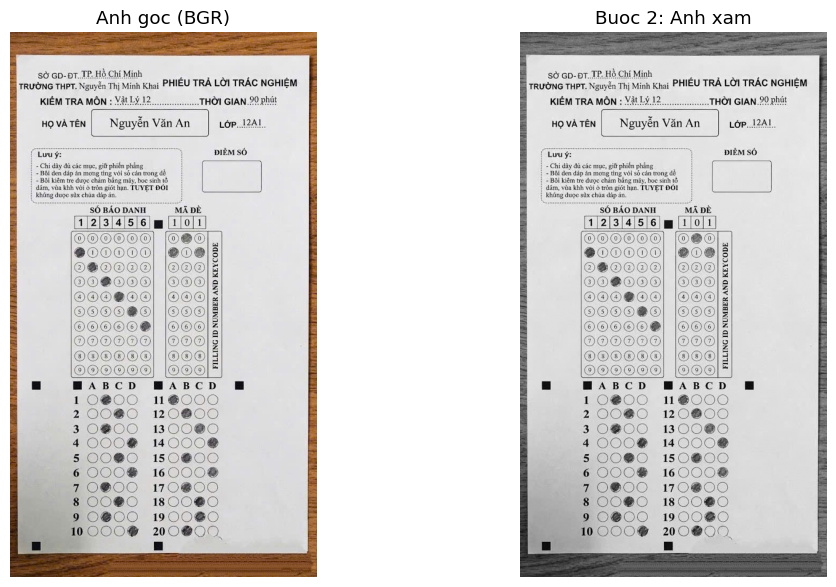

In [3]:
gray = chuyen_xam(image)
print(f'Kich thuoc anh xam: {gray.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Anh goc (BGR)')
axes[0].axis('off')
axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Buoc 2: Anh xam')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Buoc 3: Khu nhieu (Gaussian Blur)

Anh sau khu nhieu: (1024, 576)


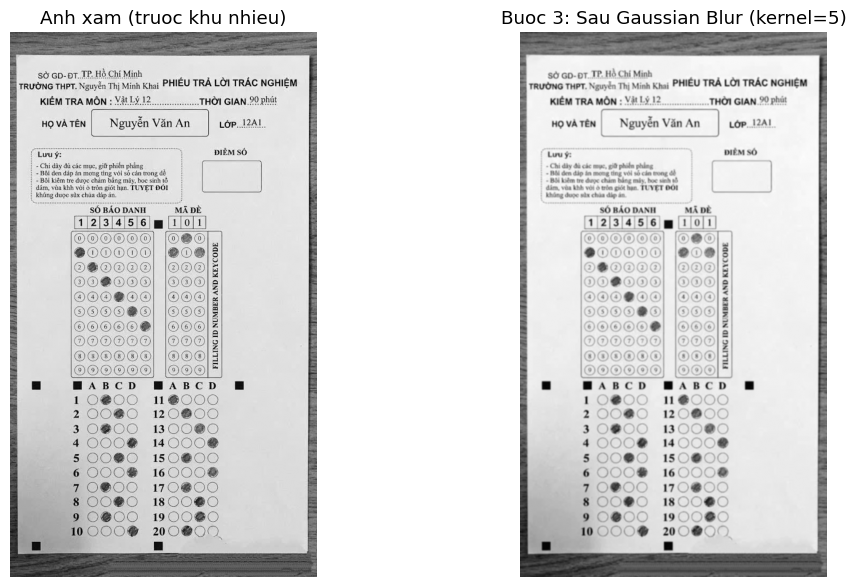

In [4]:
blurred = loc_nhieu(gray, loai_loc='gaussian', kich_thuoc=5)
print(f'Anh sau khu nhieu: {blurred.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Anh xam (truoc khu nhieu)')
axes[0].axis('off')
axes[1].imshow(blurred, cmap='gray')
axes[1].set_title('Buoc 3: Sau Gaussian Blur (kernel=5)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Buoc 4: Phat hien bien (Canny Edge Detection)

So pixel bien: 54372


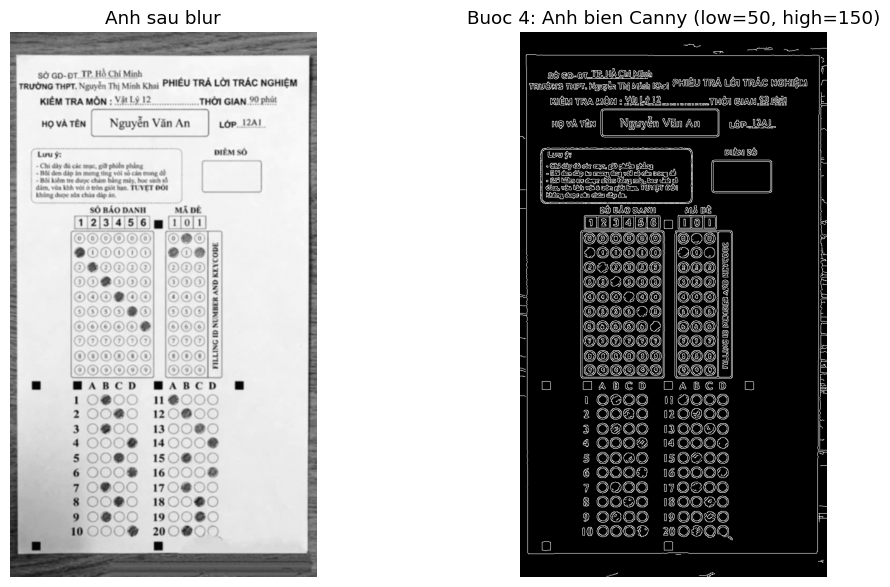

In [5]:
edges = tim_canh(blurred, nguong_thap=50, nguong_cao=150)
print(f'So pixel bien: {np.count_nonzero(edges)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(blurred, cmap='gray')
axes[0].set_title('Anh sau blur')
axes[0].axis('off')
axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Buoc 4: Anh bien Canny (low=50, high=150)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Buoc 5: Tim 4 goc toa giay

Tim thay 4 goc toa giay!
Toa do: [[  7.  39.]
 [575.  26.]
 [560. 983.]
 [ 11. 984.]]


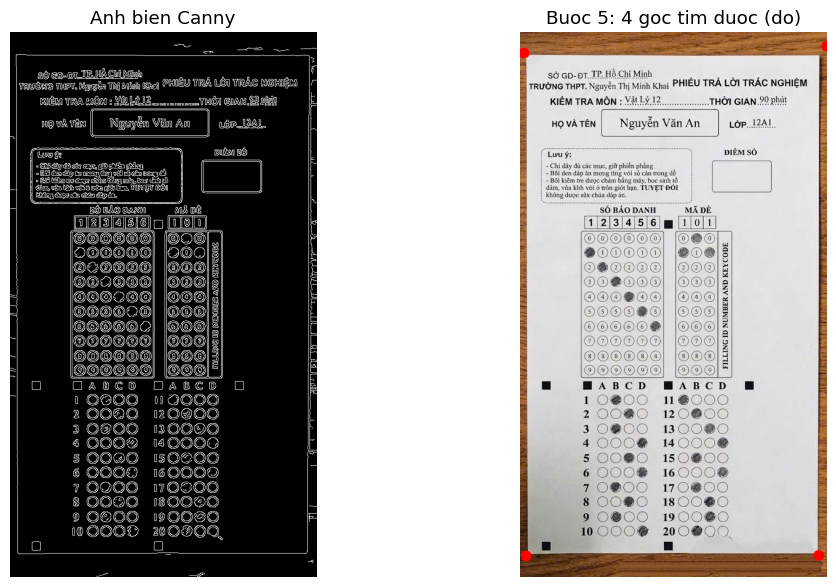

In [6]:
corners = tim_goc_giay(edges, auto_detect_cropped=True)

if corners is not None:
    print(f'Tim thay 4 goc toa giay!')
    print(f'Toa do: {corners}')
    # Ve 4 goc len anh goc de kiem tra
    vis_corners = image.copy()
    for pt in corners.reshape(-1, 2):
        cv2.circle(vis_corners, (int(pt[0]), int(pt[1])), 10, (0, 0, 255), -1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(edges, cmap='gray')
    axes[0].set_title('Anh bien Canny')
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(vis_corners, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Buoc 5: 4 goc tim duoc (do)')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Khong tim thay goc giay → se dung resize thay the o buoc 6')

## Buoc 6: Nan chinh anh (Perspective Transform)

Nan chinh bang Perspective Transform
Kich thuoc sau nan chinh: (1200, 800, 3)


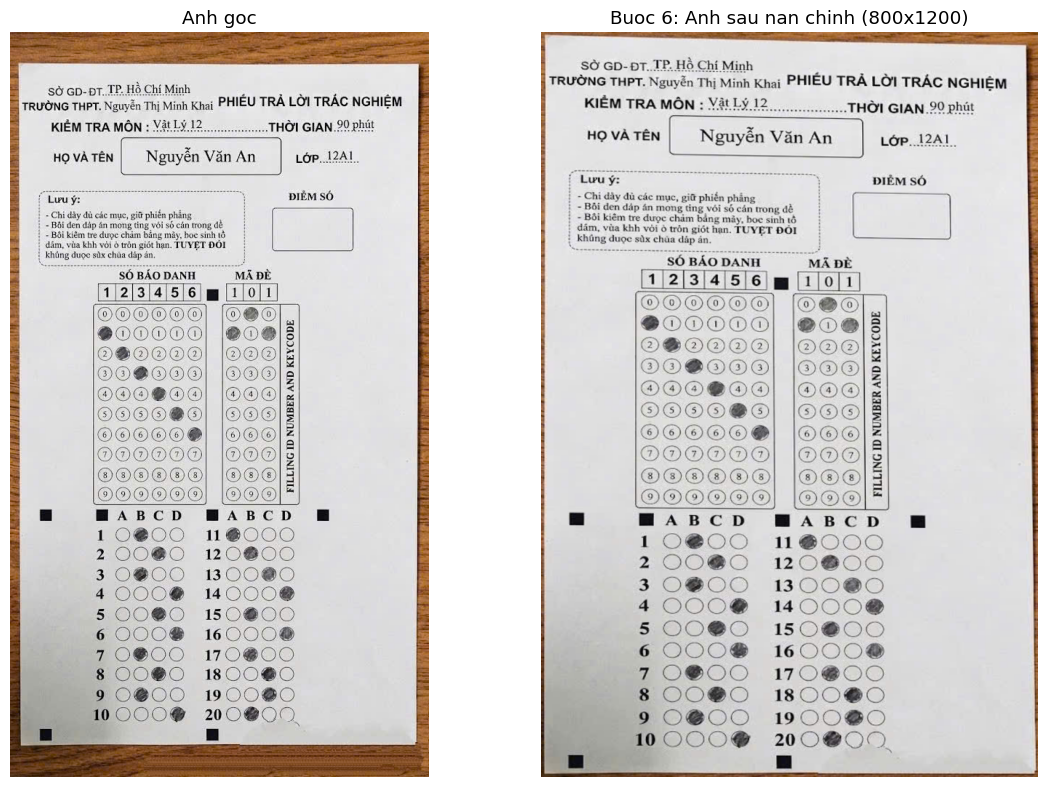

In [7]:
if corners is not None:
    warped = nan_chinh_anh(image, corners, chieu_rong=800, chieu_cao=1200)
    print('Nan chinh bang Perspective Transform')
else:
    warped = cv2.resize(image, (800, 1200))
    print('Fallback: resize ve 800x1200 (anh da cat san)')

print(f'Kich thuoc sau nan chinh: {warped.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Anh goc')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
axes[1].set_title('Buoc 6: Anh sau nan chinh (800x1200)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Buoc 7: Phat hien Anchor Markers va phan loai vung ROI

Tim thay 6 anchor markers
ROI SBD    : (80, 425, 294, 350)
ROI Ma de  : (398, 425, 144, 350)
ROI Dap an : (27, 806, 609, 358)


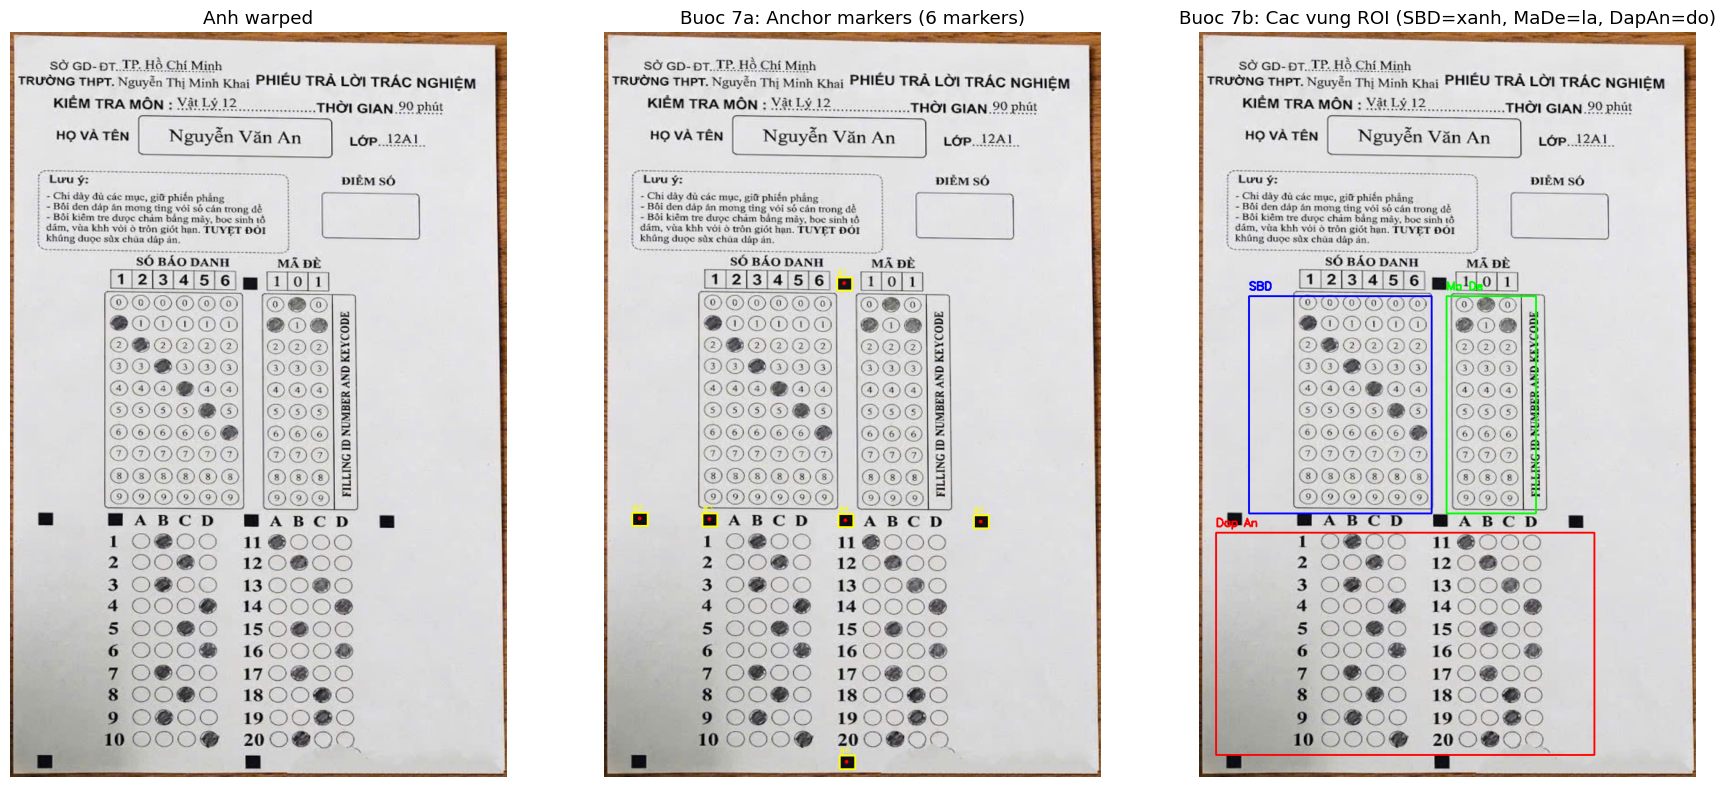

In [8]:
# Khoi tao fallback de tranh NameError neu cell nay loi
anchors = None
rois = None

try:
    anchors = phat_hien_anchor(warped)
    print(f'Tim thay {len(anchors)} anchor markers')

    rois = phan_loai_vung_roi(anchors, *warped.shape[:2])
    print(f'ROI SBD    : {rois["sbd"]}')
    print(f'ROI Ma de  : {rois["ma_de"]}')
    print(f'ROI Dap an : {rois["dap_an"]}')

except ValueError as e:
    print(f'[CANH BAO] Khong phat hien duoc anchor: {e}')
    print('Se dung fallback toa do mac dinh tu config.py')
    # Phan_loai_vung_roi co fallback built-in → goi lai khong truyen anchors
    try:
        rois = phan_loai_vung_roi([], *warped.shape[:2])
    except Exception:
        pass

# Visualization 1: Anchor markers
anh_anchor = visualize_anchors(warped, anchors)
anh_roi    = visualize_all_regions(warped, rois)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
axes[0].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
axes[0].set_title('Anh warped')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(anh_anchor, cv2.COLOR_BGR2RGB))
n_anchors = len(anchors) if anchors else 0
axes[1].set_title(f'Buoc 7a: Anchor markers ({n_anchors} markers)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(anh_roi, cv2.COLOR_BGR2RGB))
axes[2].set_title('Buoc 7b: Cac vung ROI (SBD=xanh, MaDe=la, DapAn=do)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Buoc 8: Doc ma de va So bao danh (SBD)

[Ma de] Doc bang "otsu": 101
[SBD]   Doc bang "otsu": 123456

→ Ma de  : 101
→ SBD    : 123456


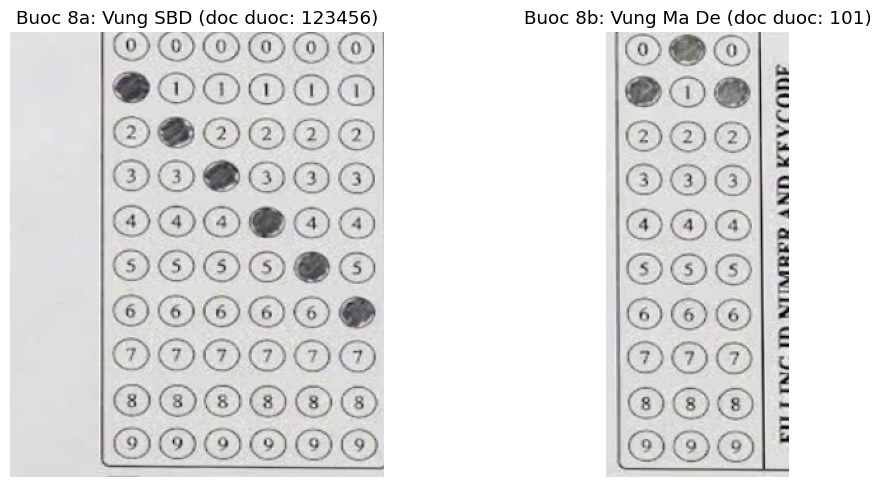

In [9]:
# Khoi tao gia tri fallback
ma_de = 'N/A'
sbd   = 'N/A'
vung_ma_de = None
vung_sbd   = None

if rois is not None:
    try:
        vung_ma_de = extract_exam_code_region(warped, *rois['ma_de'])
        vung_sbd   = extract_student_id_region(warped, *rois['sbd'])

        # Thu lan luot cac phuong phap phan nguong
        for method in ['otsu', 'adaptive', 'binary']:
            try:
                ma_de = read_exam_code(vung_ma_de, num_digits=3, threshold_method=method)
                print(f'[Ma de] Doc bang "{method}": {ma_de}')
                break
            except ValueError:
                pass

        for method in ['otsu', 'adaptive', 'binary']:
            try:
                sbd = read_student_id(vung_sbd, num_digits=6, threshold_method=method)
                print(f'[SBD]   Doc bang "{method}": {sbd}')
                break
            except ValueError:
                pass

    except Exception as e:
        print(f'[CANH BAO] Loi khi doc ma de / SBD: {e}')
else:
    print('[CANH BAO] rois = None, bo qua buoc doc SBD/Ma de')

print(f'\n→ Ma de  : {ma_de}')
print(f'→ SBD    : {sbd}')

# Visualization vung da cat
if vung_ma_de is not None and vung_sbd is not None:
    def _to_rgb(img):
        if img.ndim == 3:
            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(_to_rgb(vung_sbd), cmap='gray' if vung_sbd.ndim == 2 else None)
    axes[0].set_title(f'Buoc 8a: Vung SBD (doc duoc: {sbd})')
    axes[0].axis('off')

    axes[1].imshow(_to_rgb(vung_ma_de), cmap='gray' if vung_ma_de.ndim == 2 else None)
    axes[1].set_title(f'Buoc 8b: Vung Ma De (doc duoc: {ma_de})')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('[INFO] Khong the hien thi vung anh vi extraction that bai')

## Buoc 9: Load dap an va Cham diem

In [11]:
answer_key = {}

try:
    with open('data/answer_keys/all_answer_keys.json', 'r', encoding='utf-8') as f:
        all_keys = json.load(f)

    if ma_de in all_keys:
        answer_key = {int(k): v for k, v in all_keys[ma_de]['answers'].items()}
        print(f'Tim thay dap an cho ma de "{ma_de}" ({len(answer_key)} cau)')
    else:
        # Fallback: lay ma de dau tien co trong file
        first_key = next(iter(all_keys))
        answer_key = {int(k): v for k, v in all_keys[first_key]['answers'].items()}
        print(f'[CANH BAO] Khong tim thay ma de "{ma_de}".')
        print(f'           Dung fallback ma de "{first_key}" de demo')
        ma_de = first_key

except FileNotFoundError:
    print('[LOI] Khong tim thay file dap an: data/answer_keys/all_answer_keys.json')
except Exception as e:
    print(f'[LOI] {e}')

print(f'\nSo cau dap an: {len(answer_key)}')

Tim thay dap an cho ma de "101" (20 cau)

So cau dap an: 20


In [12]:
correct_count = None
score = None
student_answers = None

if answer_key:
    try:
        correct_count, score, student_answers = grade_from_image(
            warped_image=warped,
            answer_key=answer_key,
            num_questions=len(answer_key),
            so_bao_danh=sbd,
            ma_de=ma_de
        )
        print(f'So bao danh : {sbd}')
        print(f'Ma de       : {ma_de}')
        print(f'So cau dung : {correct_count}/{len(answer_key)}')
        print(f'Diem so     : {score:.2f}/10')
        print()
        print(f'{"Cau":>5} | {"Dap an":>8} | {"SV chon":>8} | {"Ket qua":>8}')
        print('-' * 40)
        for q in sorted(answer_key.keys()):
            sv  = student_answers.get(q, '?') if student_answers else '?'
            dap = answer_key[q]
            ok  = '✓' if sv == dap else '✗'
            print(f'{q:>5} | {dap:>8} | {sv:>8} | {ok:>8}')

    except Exception as e:
        print(f'[LOI] Cham diem that bai: {e}')
else:
    print('[CANH BAO] Khong co dap an → bo qua buoc cham diem')

   ✓ Auto-detect vùng đáp án: (27, 806, 609, 358)
   ✓ Phân đoạn adaptive threshold — shape=(1200, 800)
   ✓ Phát hiện lưới: 10 hàng × 2 cột

   KẾT QUẢ CHẤM TRẮC NGHIỆM TỰ ĐỘNG (OMR)
   Số báo danh : 123456
   Mã đề       : 101
   Số câu đúng : 6/20
   Điểm số     : 3.00/10
    Câu  Học sinh   Đáp án   Kết quả
   ----------------------------------------------
      1     B         A      ✗ ←
      2     C         C      ✓
      3     B         B      ✓
      4     D         D      ✓
      5     C         A      ✗ ←
      6     D         B      ✗ ←
      7     B         C      ✗ ←
      8     C         D      ✗ ←
      9     B         A      ✗ ←
     10     B         B      ✓
     11     A         C      ✗ ←
     12     B         D      ✗ ←
     13     C         A      ✗ ←
     14     D         B      ✗ ←
     15     B         C      ✗ ←
     16     D         D      ✓
     17     B         A      ✗ ←
     18     C         B      ✗ ←
     19     C         C      ✓
     20     B         

## Tong ket ket qua Pipeline

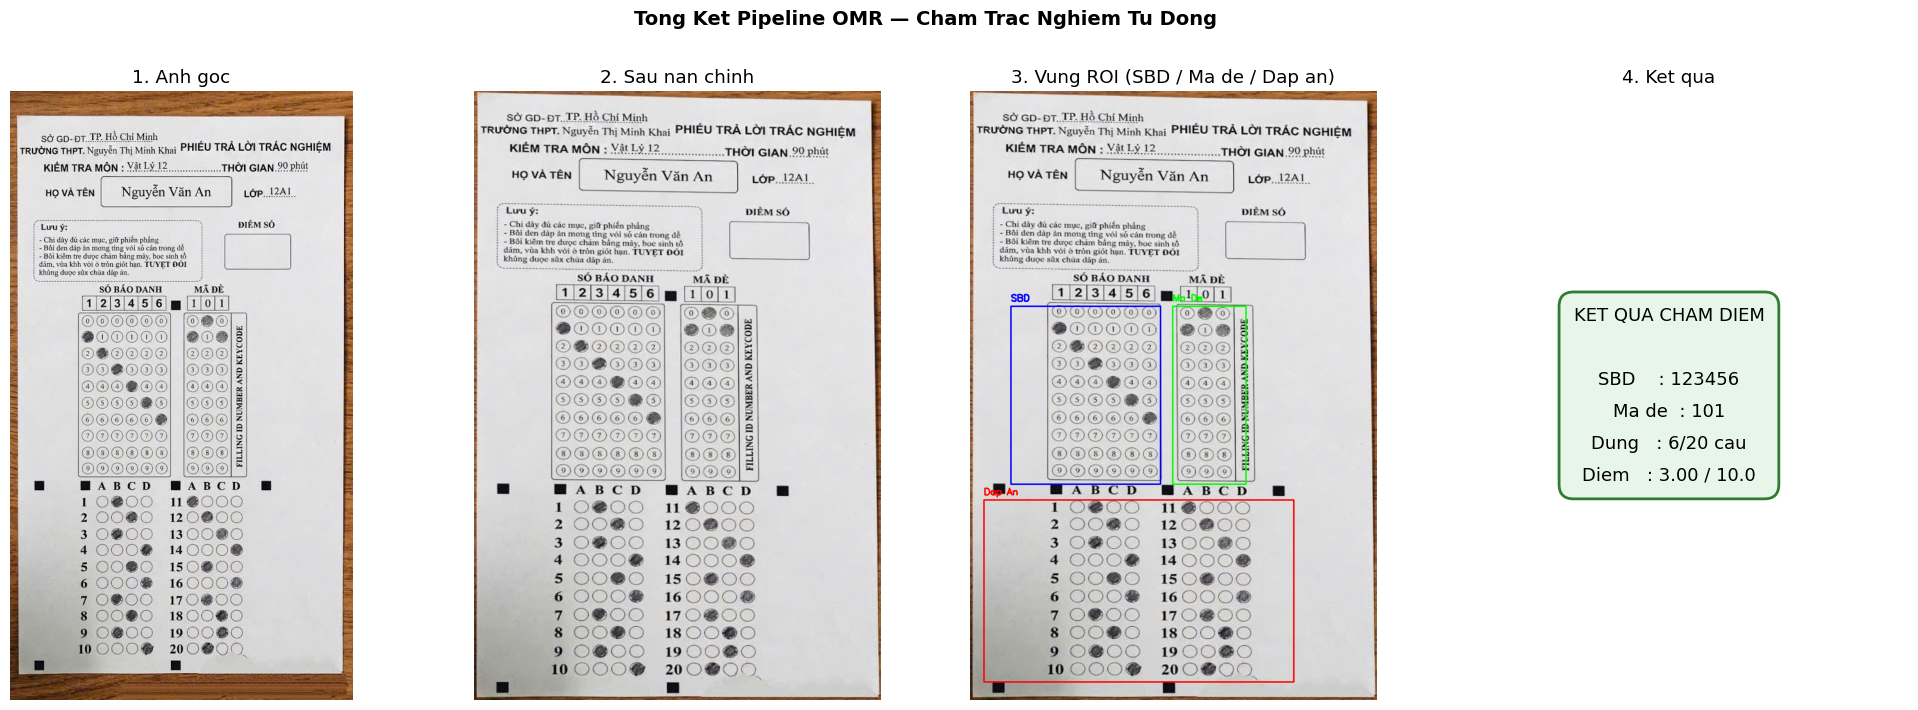


[DONE] Pipeline hoan tat!


In [13]:
# Hien thi ket qua tong the cua pipeline
fig, axes = plt.subplots(1, 4, figsize=(20, 7))

# Panel 1: Anh goc
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title('1. Anh goc')
axes[0].axis('off')

# Panel 2: Anh sau nan chinh
axes[1].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
axes[1].set_title('2. Sau nan chinh')
axes[1].axis('off')

# Panel 3: Vung ROI da phan loai
axes[2].imshow(cv2.cvtColor(anh_roi, cv2.COLOR_BGR2RGB))
axes[2].set_title('3. Vung ROI (SBD / Ma de / Dap an)')
axes[2].axis('off')

# Panel 4: Ket qua cham diem
axes[3].axis('off')
if score is not None:
    result_text = (
        f'KET QUA CHAM DIEM\n\n'
        f'SBD    : {sbd}\n'
        f'Ma de  : {ma_de}\n'
        f'Dung   : {correct_count}/{len(answer_key)} cau\n'
        f'Diem   : {score:.2f} / 10.0'
    )
    axes[3].text(
        0.5, 0.5, result_text,
        ha='center', va='center',
        fontsize=13, linespacing=2.0,
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#e8f5e9', edgecolor='#2e7d32', linewidth=2)
    )
    axes[3].set_title('4. Ket qua')
else:
    axes[3].text(0.5, 0.5, 'Cham diem\nkhong thanh cong',
                 ha='center', va='center', fontsize=12,
                 color='red')

plt.suptitle('Tong Ket Pipeline OMR — Cham Trac Nghiem Tu Dong', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n[DONE] Pipeline hoan tat!')